## 0. Imports & shared utilities

In [20]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import copy, time, gc, warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [21]:
# ── Shared constants ──────────────────────────────────────────────────────────
# Column names (must match Marta's exports)
TARGET_COL = 'y_target'
TIME_COL   = 'ts_index'
ID_COL     = 'id'
GROUP_KEYS = ['code', 'sub_code', 'sub_category', 'horizon']

# Paths — parquet files in project `data/` (cwd = repo or notebook dir)
TRAIN_PATH = 'data/train.parquet'

# Data sampling
N_SAMPLE_GROUPS = 1000   # how many groups to train on
SEQ_LEN         = 20     # time steps per window
VAL_FRAC        = 0.15   # last 15% of each group = validation

# Training
EPOCHS   = 40
PATIENCE = 6

# Block A best config — baseline for all experiments
BEST_A_HIDDEN    = 64
BEST_A_LAYERS    = 2
BEST_A_DROPOUT   = 0.2
BEST_A_BATCH     = 128
BEST_A_LR        = 1e-3
BEST_A_OPTIMIZER = 'Adam'
BEST_A_SCHEDULER = 'ReduceOnPlateau'

In [22]:
# ── Experiment log ────────────────────────────────────────────────────────────
# Every experiment appends one row. Never overwritten.
results_log = []

def log_run(run_id, block, feature_set, optimizer_name,
            lr, batch_size, epochs_run, val_mae, val_rmse, extra=''):
    """Save one experiment result."""
    results_log.append({
        'run_id':      run_id,
        'block':       block,
        'model':       'LSTM',
        'feature_set': feature_set,
        'optimizer':   optimizer_name,
        'lr':          lr,
        'batch_size':  batch_size,
        'epochs_run':  epochs_run,
        'val_mae':     val_mae,
        'val_rmse':    val_rmse,
        'extra':       extra,
    })

def show_log():
    """Display the full experiment log so far."""
    df = pd.DataFrame(results_log)
    display(df)
    return df

In [23]:
# ── LSTM model ────────────────────────────────────────────────────────────────
# input_size is set dynamically based on the feature set loaded.
# Everything else is configurable per experiment.

class LSTMForecaster(nn.Module):
    """
    Stacked LSTM -> FC head.
    Input:  (batch, seq_len, input_size)
    Output: (batch,) — predicted y_target
    """
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)       # out: (batch, seq_len, hidden_size)
        last = out[:, -1, :]        # take last time step
        return self.head(last).squeeze(-1)


class TSDataset(Dataset):
    """Simple wrapper: numpy arrays -> torch tensors."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

In [24]:
# ── Sequence builder ──────────────────────────────────────────────────────────
# Called once per group. Builds sliding windows that stay inside one time series.

def create_sequences(data: np.ndarray, seq_len: int):
    """
    data:    (T, F) — one group, sorted by time, already scaled
    seq_len: how many past steps the model sees

    Returns:
        X: (N, seq_len, F) — input windows
        y: (N,)            — next y_target (column 0)

    Example with T=5, seq_len=3:
        window 0: data[0:3] -> predict data[3, 0]
        window 1: data[1:4] -> predict data[4, 0]
        N = T - seq_len = 2
    """
    T, F = data.shape
    N = T - seq_len
    if N <= 0:
        return np.empty((0, seq_len, F), dtype=np.float32), np.empty((0,), dtype=np.float32)
    X = np.empty((N, seq_len, F), dtype=np.float32)
    y = np.empty((N,), dtype=np.float32)
    for i in range(N):
        X[i] = data[i : i + seq_len]    # (seq_len, F)
        y[i] = data[i + seq_len, 0]     # column 0 = y_target
    return X, y

In [25]:
# ── Data loader ───────────────────────────────────────────────────────────────
# Matches the CNN notebook's load_feature_set() logic exactly:
#   1. Load Marta's exported parquet (features only)
#   2. Load train.parquet (metadata: id, ts_index, y_target, group keys)
#   3. Column-bind them
#   4. Sample N groups
#   5. Per-group: sort by ts_index, temporal split (85/15)
#   6. Fit ONE RobustScaler on all training rows combined
#   7. Build sliding windows per group
#
# Only difference from CNN: sequences are (N, seq_len, F) not (N, F, seq_len)
#   because LSTM uses batch_first=True, CNN uses Conv1d channels-first.

def load_feature_set(feat_path, n_sample=N_SAMPLE_GROUPS, seq_len=SEQ_LEN):
    """
    Load one of Marta's feature set exports + train metadata.
    Returns X_train, y_train, X_val, y_val, input_size.
    """
    # --- Load metadata (id, ts_index, y_target, group keys) ---
    meta_cols = [ID_COL, TIME_COL, TARGET_COL] + GROUP_KEYS
    df_meta = pd.read_parquet(TRAIN_PATH, columns=meta_cols)

    # --- Load Marta's preprocessed features ---
    df_feats = pd.read_parquet(feat_path)
    feature_cols = [c for c in df_feats.columns
                    if c not in GROUP_KEYS + [TARGET_COL, TIME_COL, ID_COL, 'weight']]
    model_cols = [TARGET_COL] + feature_cols
    input_size = len(model_cols)

    # --- Column-bind (same rows, same order) ---
    assert len(df_meta) == len(df_feats), f'Row mismatch: {len(df_meta)} vs {len(df_feats)}'
    df = pd.concat([df_meta, df_feats[feature_cols]], axis=1)
    del df_meta, df_feats; gc.collect()
    print(f'  Loaded: {len(df):,} rows x {input_size} input channels ({len(feature_cols)} features)')

    # --- Sample complete groups ---
    unique_keys  = df[GROUP_KEYS].drop_duplicates()
    sampled_keys = unique_keys.sample(n=min(n_sample, len(unique_keys)), random_state=SEED)
    df = df.merge(sampled_keys, on=GROUP_KEYS, how='inner')
    print(f'  Sampled {len(sampled_keys)} groups -> {len(df):,} rows')

    # --- Per-group temporal split ---
    group_train, group_val = {}, {}
    for name, gdf in df.groupby(GROUP_KEYS, sort=False):
        gdf = gdf.sort_values(TIME_COL)
        gdf[model_cols] = gdf[model_cols].ffill().bfill().fillna(0.0)
        vals = gdf[model_cols].values.astype(np.float32)
        if len(vals) < seq_len + 1:
            continue
        split = int(len(vals) * (1 - VAL_FRAC))
        group_train[name] = vals[:split]
        group_val[name]   = vals[split:]

    # --- Fit ONE scaler on all training rows (matches CNN logic) ---
    all_train = np.concatenate(list(group_train.values()))
    scaler = RobustScaler().fit(all_train)
    del all_train; gc.collect()

    # --- Build sliding windows per group ---
    def _make_seqs(groups):
        Xs, ys = [], []
        for vals in groups.values():
            scaled = scaler.transform(vals).astype(np.float32)
            X, y = create_sequences(scaled, seq_len)
            if len(X) > 0:
                Xs.append(X)
                ys.append(y)
        if not Xs:
            return np.empty((0, seq_len, input_size), dtype=np.float32), np.empty((0,), dtype=np.float32)
        return np.concatenate(Xs), np.concatenate(ys)

    X_tr, y_tr = _make_seqs(group_train)
    X_va, y_va = _make_seqs(group_val)
    del df, group_train, group_val; gc.collect()

    print(f'  Train: {len(X_tr):,} | Val: {len(X_va):,} | input_size: {input_size}')
    return X_tr, y_tr, X_va, y_va, input_size

In [26]:
# ── Training utilities ────────────────────────────────────────────────────────

def make_optimizer(name, params, lr, weight_decay=1e-5):
    """Create optimizer by name."""
    if name == 'Adam':    return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == 'SGD':     return torch.optim.SGD(params, lr=lr, weight_decay=weight_decay, momentum=0.9)
    if name == 'RMSProp': return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    raise ValueError(f'Unknown optimizer: {name}')


def make_scheduler(name, optimizer):
    """Create LR scheduler by name."""
    if name == 'ReduceOnPlateau': return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)
    if name == 'StepLR':          return torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    if name == 'CosineAnnealing': return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    if name == 'None':            return None
    raise ValueError(f'Unknown scheduler: {name}')


def train_and_eval(model, train_loader, val_loader,
                   optimizer_name='Adam', lr=1e-3,
                   scheduler_name='ReduceOnPlateau',
                   patience=PATIENCE, epochs=EPOCHS,
                   save_path='best_exp.pt'):
    """
    Train the model, track val MAE/RMSE, apply early stopping.
    Returns (best_val_mae, best_val_rmse, epochs_run, history).
    """
    criterion = nn.HuberLoss(delta=1.0)
    optimizer = make_optimizer(optimizer_name, model.parameters(), lr)
    scheduler = make_scheduler(scheduler_name, optimizer)

    best_val_loss = float('inf')
    best_mae = best_rmse = float('inf')
    patience_ctr = 0
    history = {'train': [], 'val': [], 'mae': []}
    epoch_run = 0

    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        t_loss, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item() * len(yb); n += len(yb)
        train_loss = t_loss / n

        # ── Validate ──
        model.eval()
        v_loss, n = 0.0, 0
        preds_all, tgts_all = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                p = model(xb)
                v_loss += criterion(p, yb).item() * len(yb); n += len(yb)
                preds_all.append(p.cpu()); tgts_all.append(yb.cpu())
        val_loss = v_loss / n
        p_cat = torch.cat(preds_all); t_cat = torch.cat(tgts_all)
        val_mae  = torch.mean(torch.abs(p_cat - t_cat)).item()
        val_rmse = torch.sqrt(torch.mean((p_cat - t_cat) ** 2)).item()

        # ── Scheduler ──
        if scheduler is not None:
            if scheduler_name == 'ReduceOnPlateau': scheduler.step(val_loss)
            else: scheduler.step()

        history['train'].append(train_loss)
        history['val'].append(val_loss)
        history['mae'].append(val_mae)
        epoch_run = epoch

        # ── Checkpoint ──
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_mae  = val_mae
            best_rmse = val_rmse
            patience_ctr = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_ctr += 1

        if epoch % 5 == 0 or patience_ctr >= patience:
            print(f'  ep {epoch:3d} | train={train_loss:.5f} val={val_loss:.5f} MAE={val_mae:.5f}')

        if patience_ctr >= patience:
            print(f'  -> Early stop at epoch {epoch}')
            break

    return best_mae, best_rmse, epoch_run, history


def plot_history(history, title):
    """Two-panel plot: Huber loss + val MAE."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    axes[0].plot(history['train'], label='train'); axes[0].plot(history['val'], label='val')
    axes[0].set_title(f'{title} — Huber loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history['mae'], color='orange', label='val MAE')
    axes[1].set_title(f'{title} — Val MAE'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

---
## Block B — Feature Sets

**Fixed:** LSTM architecture from Block A, default hyperparameters.  
**Variable:** which exported feature-set parquet to use (all under `data/`).

| Exp | File | Description |
|-----|------|-------------|
| B1  | set_global_uncorr | Global decorrelated features (all horizons) |
| B2  | set_h1_uncorr | Decorrelated features for horizon 1 |
| B3  | set_h3_uncorr | Decorrelated features for horizon 3 |
| B4  | set_h10_uncorr | Decorrelated features for horizon 10 |
| B5  | set_h25_uncorr | Decorrelated features for horizon 25 |

After running B1–B5, the best feature set (lowest val MAE) is fixed for Block C.

In [27]:
# Feature set parquet files in `data/` (5 exports)
FEATURE_SETS = {
    'set_global_uncorr': 'data/set_global_uncorr.parquet',
    'set_h1_uncorr':     'data/set_h1_uncorr.parquet',
    'set_h3_uncorr':     'data/set_h3_uncorr.parquet',
    'set_h10_uncorr':    'data/set_h10_uncorr.parquet',
    'set_h25_uncorr':    'data/set_h25_uncorr.parquet',
}

=== B1: set_global_core (10 features) ===
  Loaded: 5,337,414 rows x 11 input channels (10 features)
  Sampled 1000 groups -> 140,712 rows
  Train: 99,461 | Val: 4,717 | input_size: 11
  ep   5 | train=27.51109 val=32.59133 MAE=32.90229
  ep  10 | train=24.91605 val=31.73833 MAE=32.06545
  ep  15 | train=25.03064 val=31.44610 MAE=31.75760
  ep  18 | train=23.49044 val=31.13638 MAE=31.44684
  -> Early stop at epoch 18


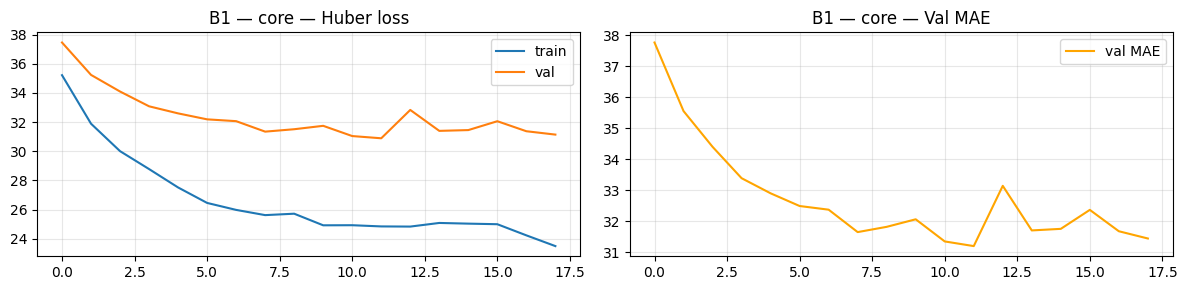

10829

In [28]:
# ── B1: global uncorrelated ───────────────────────────────────────────────────
print('=== B1: set_global_uncorr ===')
X_tr, y_tr, X_va, y_va, in_sz = load_feature_set(FEATURE_SETS['set_global_uncorr'])

model_b1 = LSTMForecaster(input_size=in_sz, hidden_size=BEST_A_HIDDEN,
    num_layers=BEST_A_LAYERS, dropout=BEST_A_DROPOUT).to(DEVICE)

tr_l = DataLoader(TSDataset(X_tr, y_tr), batch_size=BEST_A_BATCH, shuffle=True, num_workers=0)
va_l = DataLoader(TSDataset(X_va, y_va), batch_size=BEST_A_BATCH, shuffle=False, num_workers=0)

mae, rmse, ep, hist = train_and_eval(model_b1, tr_l, va_l,
    optimizer_name=BEST_A_OPTIMIZER, lr=BEST_A_LR,
    scheduler_name=BEST_A_SCHEDULER, save_path='best_B1.pt')
plot_history(hist, 'B1 — global_uncorr')
log_run('B1-global_uncorr', 'B', 'set_global_uncorr', BEST_A_OPTIMIZER,
        BEST_A_LR, BEST_A_BATCH, ep, mae, rmse, 'B1-feature_set')
del X_tr, y_tr, X_va, y_va; gc.collect()

=== B2: set_global_uncorr (16 features) ===
  Loaded: 5,337,414 rows x 17 input channels (16 features)
  Sampled 1000 groups -> 140,712 rows
  Train: 99,461 | Val: 4,717 | input_size: 17
  ep   5 | train=27.74055 val=32.10793 MAE=32.42193
  ep  10 | train=25.33823 val=30.45358 MAE=30.76747
  ep  15 | train=23.81747 val=31.18404 MAE=31.49785
  ep  20 | train=22.93040 val=30.11129 MAE=30.42215
  ep  25 | train=22.68019 val=29.97650 MAE=30.29049
  ep  30 | train=22.17426 val=30.17594 MAE=30.48880
  ep  31 | train=22.19620 val=30.34113 MAE=30.65536
  -> Early stop at epoch 31


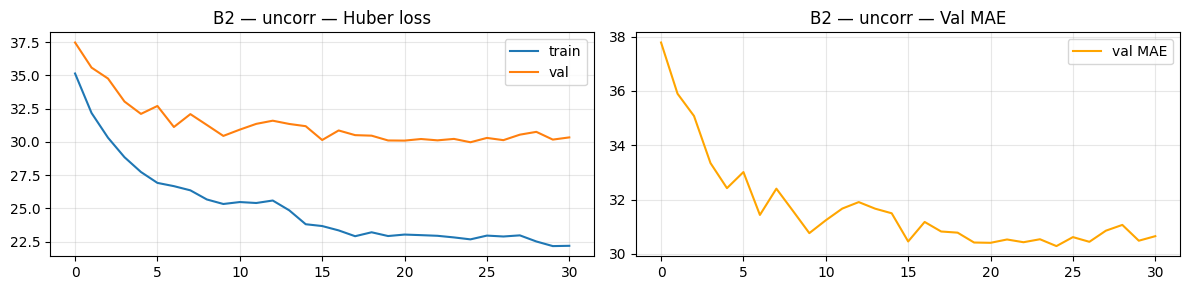

8317

In [29]:
# ── B2: horizon 1 uncorrelated ────────────────────────────────────────────────
print('=== B2: set_h1_uncorr ===')
X_tr, y_tr, X_va, y_va, in_sz = load_feature_set(FEATURE_SETS['set_h1_uncorr'])

model_b2 = LSTMForecaster(input_size=in_sz, hidden_size=BEST_A_HIDDEN,
    num_layers=BEST_A_LAYERS, dropout=BEST_A_DROPOUT).to(DEVICE)

tr_l = DataLoader(TSDataset(X_tr, y_tr), batch_size=BEST_A_BATCH, shuffle=True, num_workers=0)
va_l = DataLoader(TSDataset(X_va, y_va), batch_size=BEST_A_BATCH, shuffle=False, num_workers=0)

mae, rmse, ep, hist = train_and_eval(model_b2, tr_l, va_l,
    optimizer_name=BEST_A_OPTIMIZER, lr=BEST_A_LR,
    scheduler_name=BEST_A_SCHEDULER, save_path='best_B2.pt')
plot_history(hist, 'B2 — h1_uncorr')
log_run('B2-h1_uncorr', 'B', 'set_h1_uncorr', BEST_A_OPTIMIZER,
        BEST_A_LR, BEST_A_BATCH, ep, mae, rmse, 'B2-feature_set')
del X_tr, y_tr, X_va, y_va; gc.collect()

=== B3: set_global_support (20 features) ===
  Loaded: 5,337,414 rows x 21 input channels (20 features)
  Sampled 1000 groups -> 140,712 rows
  Train: 99,461 | Val: 4,717 | input_size: 21
  ep   5 | train=27.74015 val=33.13128 MAE=33.44535
  ep  10 | train=25.15217 val=31.33854 MAE=31.65007
  ep  15 | train=24.87360 val=31.30043 MAE=31.61493
  ep  20 | train=24.68699 val=32.23653 MAE=32.54831
  ep  25 | train=22.82557 val=30.52811 MAE=30.83903
  ep  28 | train=22.10814 val=30.47465 MAE=30.78303
  -> Early stop at epoch 28


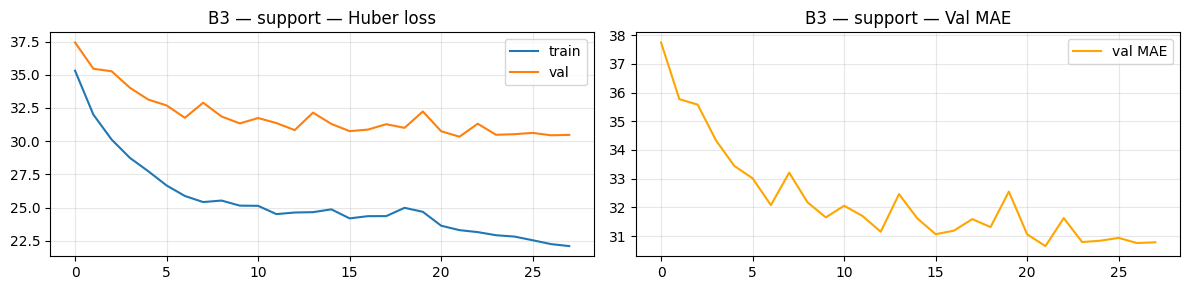

8471

In [30]:
# ── B3: horizon 3 uncorrelated ────────────────────────────────────────────────
print('=== B3: set_h3_uncorr ===')
X_tr, y_tr, X_va, y_va, in_sz = load_feature_set(FEATURE_SETS['set_h3_uncorr'])

model_b3 = LSTMForecaster(input_size=in_sz, hidden_size=BEST_A_HIDDEN,
    num_layers=BEST_A_LAYERS, dropout=BEST_A_DROPOUT).to(DEVICE)

tr_l = DataLoader(TSDataset(X_tr, y_tr), batch_size=BEST_A_BATCH, shuffle=True, num_workers=0)
va_l = DataLoader(TSDataset(X_va, y_va), batch_size=BEST_A_BATCH, shuffle=False, num_workers=0)

mae, rmse, ep, hist = train_and_eval(model_b3, tr_l, va_l,
    optimizer_name=BEST_A_OPTIMIZER, lr=BEST_A_LR,
    scheduler_name=BEST_A_SCHEDULER, save_path='best_B3.pt')
plot_history(hist, 'B3 — h3_uncorr')
log_run('B3-h3_uncorr', 'B', 'set_h3_uncorr', BEST_A_OPTIMIZER,
        BEST_A_LR, BEST_A_BATCH, ep, mae, rmse, 'B3-feature_set')
del X_tr, y_tr, X_va, y_va; gc.collect()

In [ ]:
# ── B4: horizon 10 uncorrelated ───────────────────────────────────────────────
print('=== B4: set_h10_uncorr ===')
X_tr, y_tr, X_va, y_va, in_sz = load_feature_set(FEATURE_SETS['set_h10_uncorr'])

model_b4 = LSTMForecaster(input_size=in_sz, hidden_size=BEST_A_HIDDEN,
    num_layers=BEST_A_LAYERS, dropout=BEST_A_DROPOUT).to(DEVICE)

tr_l = DataLoader(TSDataset(X_tr, y_tr), batch_size=BEST_A_BATCH, shuffle=True, num_workers=0)
va_l = DataLoader(TSDataset(X_va, y_va), batch_size=BEST_A_BATCH, shuffle=False, num_workers=0)

mae, rmse, ep, hist = train_and_eval(model_b4, tr_l, va_l,
    optimizer_name=BEST_A_OPTIMIZER, lr=BEST_A_LR,
    scheduler_name=BEST_A_SCHEDULER, save_path='best_B4.pt')
plot_history(hist, 'B4 — h10_uncorr')
log_run('B4-h10_uncorr', 'B', 'set_h10_uncorr', BEST_A_OPTIMIZER,
        BEST_A_LR, BEST_A_BATCH, ep, mae, rmse, 'B4-feature_set')
del X_tr, y_tr, X_va, y_va; gc.collect()

In [ ]:
# ── B5: horizon 25 uncorrelated ───────────────────────────────────────────────
print('=== B5: set_h25_uncorr ===')
X_tr, y_tr, X_va, y_va, in_sz = load_feature_set(FEATURE_SETS['set_h25_uncorr'])

model_b5 = LSTMForecaster(input_size=in_sz, hidden_size=BEST_A_HIDDEN,
    num_layers=BEST_A_LAYERS, dropout=BEST_A_DROPOUT).to(DEVICE)

tr_l = DataLoader(TSDataset(X_tr, y_tr), batch_size=BEST_A_BATCH, shuffle=True, num_workers=0)
va_l = DataLoader(TSDataset(X_va, y_va), batch_size=BEST_A_BATCH, shuffle=False, num_workers=0)

mae, rmse, ep, hist = train_and_eval(model_b5, tr_l, va_l,
    optimizer_name=BEST_A_OPTIMIZER, lr=BEST_A_LR,
    scheduler_name=BEST_A_SCHEDULER, save_path='best_B5.pt')
plot_history(hist, 'B5 — h25_uncorr')
log_run('B5-h25_uncorr', 'B', 'set_h25_uncorr', BEST_A_OPTIMIZER,
        BEST_A_LR, BEST_A_BATCH, ep, mae, rmse, 'B5-feature_set')
del X_tr, y_tr, X_va, y_va; gc.collect()

In [31]:
# ── Pick the winner from Block B ──────────────────────────────────────────────
df_log = show_log()
block_b = df_log[df_log['block'] == 'B'].sort_values('val_mae')

BEST_B_FEATURE_SET = block_b.iloc[0]['feature_set']
BEST_B_FILE = FEATURE_SETS[BEST_B_FEATURE_SET]
print(f'\n-> Best feature set: {BEST_B_FEATURE_SET}  (MAE={block_b.iloc[0]["val_mae"]:.5f})')
print(f'   Carried forward to Block C.')

# Reload best feature set for remaining experiments
X_train_best, y_train_best, X_val_best, y_val_best, INPUT_SIZE_BEST = load_feature_set(BEST_B_FILE)

,run_id,block,model,feature_set,optimizer,lr,batch_size,epochs_run,val_mae,val_rmse,extra
0,B1-core,B,LSTM,set_global_core,Adam,0.001,128,18,31.202137,182.312332,B1-feature_set
1,B2-uncorr,B,LSTM,set_global_uncorr,Adam,0.001,128,31,30.290491,174.800430,B2-feature_set
2,B3-support,B,LSTM,set_global_support,Adam,0.001,128,28,30.650831,177.125397,B3-feature_set



-> Best feature set: set_global_uncorr  (MAE=30.29049)
   Carried forward to Block C.
  Loaded: 5,337,414 rows x 17 input channels (16 features)
  Sampled 1000 groups -> 140,712 rows
  Train: 99,461 | Val: 4,717 | input_size: 17


---
## Block C — Gradient Descent & Training

**Fixed:** LSTM from A, best feature set from B.  
**Variable:** one hyperparameter at a time.

| Exp | Variable | Values tested |
|-----|----------|---------------|
| C1  | Optimizer | SGD, Adam, RMSProp |
| C2  | Learning rate | 1e-4, 1e-3, 1e-2 |
| C3  | Batch size | 32, 64, 128 |
| C4  | LR scheduler | StepLR, CosineAnnealing, ReduceOnPlateau |
| C5  | Early stopping patience | 5, 10 |

In [32]:
# Helper: make DataLoaders from the best feature set
def make_loaders(X_tr, y_tr, X_va, y_va, batch_size):
    tr = DataLoader(TSDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    va = DataLoader(TSDataset(X_va, y_va), batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return tr, va

# Helper: create a fresh model with Block A defaults + best input_size
def fresh_model():
    torch.manual_seed(SEED)
    return LSTMForecaster(
        input_size  = INPUT_SIZE_BEST,
        hidden_size = BEST_A_HIDDEN,
        num_layers  = BEST_A_LAYERS,
        dropout     = BEST_A_DROPOUT,
    ).to(DEVICE)

=== C1: Optimizer ===

-- SGD --
  ep   5 | train=36.62004 val=40.39161 MAE=40.72538
  ep  10 | train=35.38415 val=39.45257 MAE=39.77327
  ep  15 | train=34.77105 val=38.88160 MAE=39.19720
  ep  20 | train=34.35981 val=38.43209 MAE=38.74783
  ep  25 | train=34.01036 val=38.48256 MAE=38.79693
  ep  30 | train=33.61831 val=38.15332 MAE=38.46787
  ep  35 | train=33.38930 val=37.61625 MAE=37.92883
  ep  40 | train=33.22909 val=37.42509 MAE=37.73631


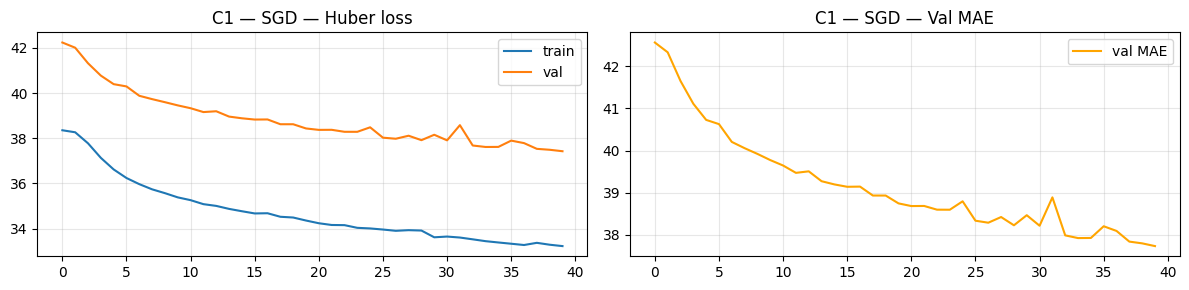


-- Adam --
  ep   5 | train=27.44875 val=32.79480 MAE=33.14489
  ep  10 | train=26.16740 val=31.96593 MAE=32.27882
  ep  15 | train=23.58119 val=30.59528 MAE=30.90580
  ep  20 | train=23.02665 val=30.79344 MAE=31.10272
  ep  25 | train=23.00537 val=30.02191 MAE=30.33028
  ep  30 | train=22.07638 val=30.12498 MAE=30.43347
  ep  31 | train=21.92590 val=30.21035 MAE=30.51857
  -> Early stop at epoch 31


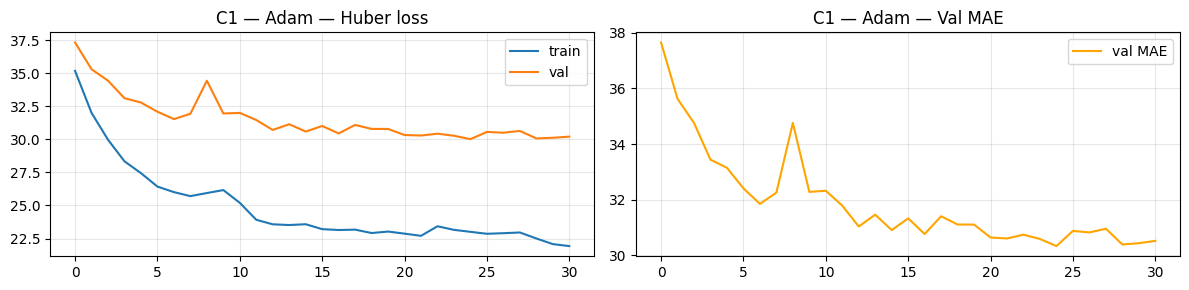


-- RMSProp --
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep  10 | train=22.78327 val=30.36397 MAE=30.67185
  ep  15 | train=22.64170 val=31.03813 MAE=31.40532
  ep  20 | train=21.93283 val=30.38422 MAE=30.69461
  ep  25 | train=21.70251 val=29.19830 MAE=29.50634
  ep  29 | train=21.43820 val=29.88316 MAE=30.20553
  -> Early stop at epoch 29


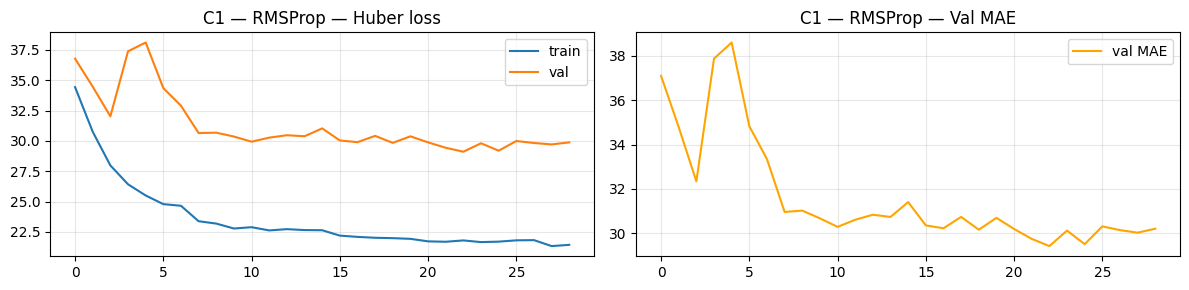

In [33]:
# ── C1: Optimizer ─────────────────────────────────────────────────────────────
print('=== C1: Optimizer ===')
tr_l, va_l = make_loaders(X_train_best, y_train_best, X_val_best, y_val_best, BEST_A_BATCH)

for opt_name in ['SGD', 'Adam', 'RMSProp']:
    print(f'\n-- {opt_name} --')
    m = fresh_model()
    mae, rmse, ep, hist = train_and_eval(m, tr_l, va_l,
        optimizer_name=opt_name, lr=BEST_A_LR,
        scheduler_name=BEST_A_SCHEDULER, save_path=f'best_C1_{opt_name}.pt')
    plot_history(hist, f'C1 — {opt_name}')
    log_run(f'C1-{opt_name}', 'C', BEST_B_FEATURE_SET, opt_name,
            BEST_A_LR, BEST_A_BATCH, ep, mae, rmse, 'C1-optimizer')

In [34]:
df_c1 = pd.DataFrame(results_log)
df_c1 = df_c1[df_c1['extra'] == 'C1-optimizer'].sort_values('val_mae')
display(df_c1[['run_id', 'optimizer', 'val_mae', 'val_rmse', 'epochs_run']])
BEST_C1_OPTIMIZER = df_c1.iloc[0]['optimizer']
print(f'\n-> Best optimizer: {BEST_C1_OPTIMIZER}')

,run_id,optimizer,val_mae,val_rmse,epochs_run
5,C1-RMSProp,RMSProp,29.420172,172.583374,29
4,C1-Adam,Adam,30.330282,174.937408,31
3,C1-SGD,SGD,37.736313,231.302628,40



-> Best optimizer: RMSProp


=== C2: Learning rate ===

-- lr=0.0001 --
  ep   5 | train=34.89869 val=38.70340 MAE=39.01292
  ep  10 | train=32.45965 val=36.61119 MAE=36.91967
  ep  15 | train=30.37597 val=35.22943 MAE=35.53856
  ep  20 | train=28.61125 val=33.96631 MAE=34.27617
  ep  25 | train=27.16421 val=32.73104 MAE=33.03884
  ep  30 | train=25.97482 val=32.28062 MAE=32.59710
  ep  35 | train=25.14508 val=31.76281 MAE=32.07211
  ep  40 | train=24.41395 val=31.53407 MAE=31.84075
  -> Early stop at epoch 40


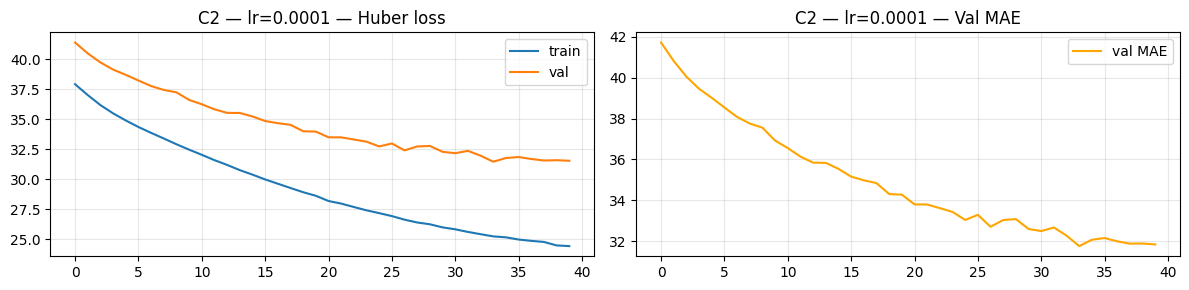


-- lr=0.001 --
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep  10 | train=22.78327 val=30.36397 MAE=30.67185
  ep  15 | train=22.64170 val=31.03813 MAE=31.40532
  ep  20 | train=21.93283 val=30.38422 MAE=30.69461
  ep  25 | train=21.70251 val=29.19830 MAE=29.50634
  ep  29 | train=21.43820 val=29.88316 MAE=30.20553
  -> Early stop at epoch 29


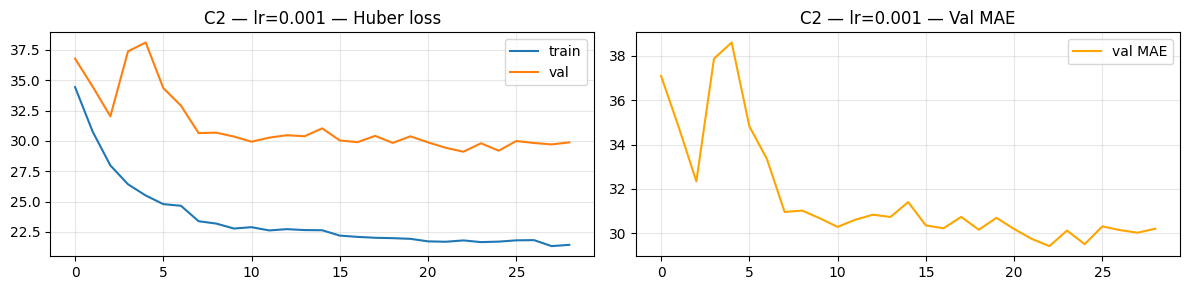


-- lr=0.01 --
  ep   5 | train=28.94746 val=34.76020 MAE=35.09850
  ep  10 | train=29.23469 val=35.96762 MAE=36.28127
  ep  15 | train=28.57662 val=37.64647 MAE=38.12257
  ep  20 | train=27.28412 val=32.68643 MAE=33.00803
  ep  25 | train=26.97713 val=31.98587 MAE=32.30247
  ep  27 | train=25.85721 val=31.71966 MAE=32.03032
  -> Early stop at epoch 27


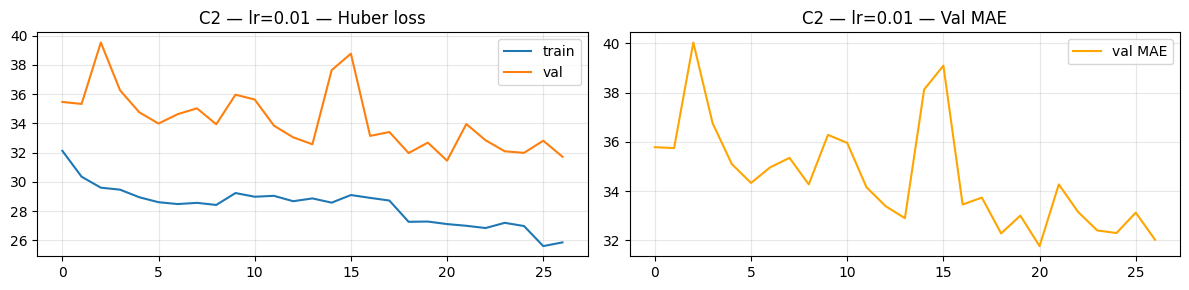

In [35]:
# ── C2: Learning rate ─────────────────────────────────────────────────────────
print('=== C2: Learning rate ===')
for lr in [1e-4, 1e-3, 1e-2]:
    print(f'\n-- lr={lr} --')
    m = fresh_model()
    mae, rmse, ep, hist = train_and_eval(m, tr_l, va_l,
        optimizer_name=BEST_C1_OPTIMIZER, lr=lr,
        scheduler_name=BEST_A_SCHEDULER, save_path=f'best_C2_lr{lr}.pt')
    plot_history(hist, f'C2 — lr={lr}')
    log_run(f'C2-lr{lr}', 'C', BEST_B_FEATURE_SET, BEST_C1_OPTIMIZER,
            lr, BEST_A_BATCH, ep, mae, rmse, 'C2-lr')

In [36]:
df_c2 = pd.DataFrame(results_log)
df_c2 = df_c2[df_c2['extra'] == 'C2-lr'].sort_values('val_mae')
display(df_c2[['run_id', 'lr', 'val_mae', 'val_rmse', 'epochs_run']])
BEST_C2_LR = df_c2.iloc[0]['lr']
print(f'\n-> Best LR: {BEST_C2_LR}')

,run_id,lr,val_mae,val_rmse,epochs_run
7,C2-lr0.001,0.0010,29.420172,172.583374,29
6,C2-lr0.0001,0.0001,31.760750,197.338882,40
8,C2-lr0.01,0.0100,31.772163,186.667267,27



-> Best LR: 0.001


=== C3: Batch size ===

-- batch_size=32 --
  ep   5 | train=26.11596 val=32.03268 MAE=32.38926
  ep  10 | train=25.55145 val=32.41275 MAE=32.71986
  ep  15 | train=23.67276 val=31.75320 MAE=32.05917
  ep  18 | train=22.99166 val=31.49727 MAE=31.80245
  -> Early stop at epoch 18


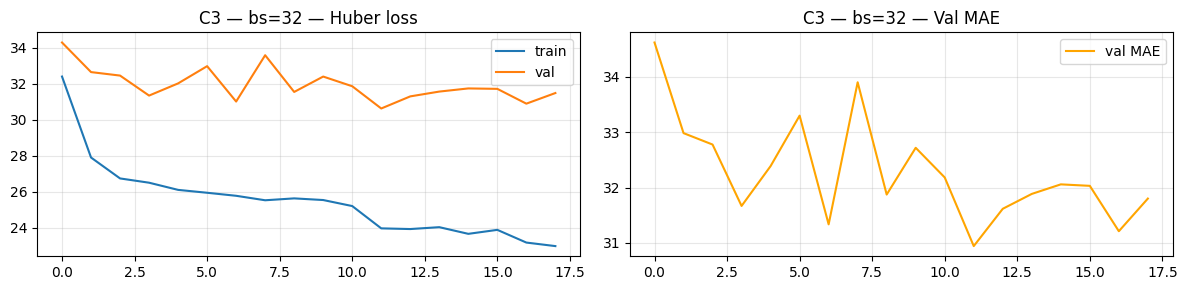


-- batch_size=64 --
  ep   5 | train=25.82674 val=32.64744 MAE=33.12027
  ep  10 | train=23.28554 val=30.34808 MAE=30.65531
  ep  15 | train=22.52412 val=30.10245 MAE=30.41365
  ep  20 | train=21.79350 val=30.31098 MAE=30.61992
  ep  25 | train=21.54371 val=29.91599 MAE=30.22239
  ep  27 | train=21.37189 val=30.02219 MAE=30.32972
  -> Early stop at epoch 27


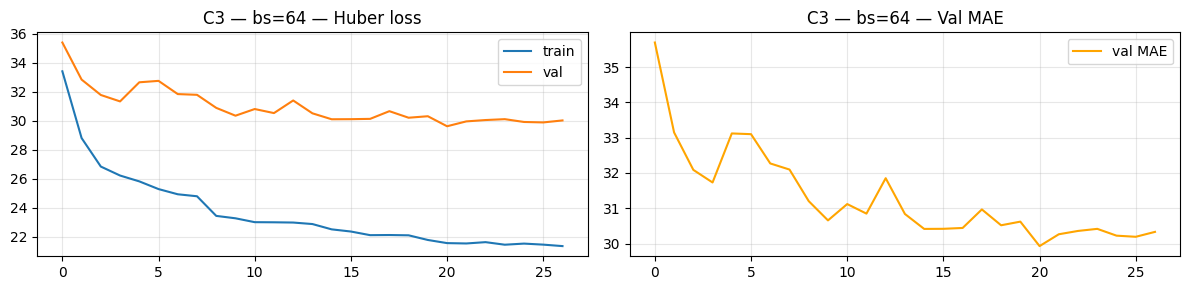


-- batch_size=128 --
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep  10 | train=22.78327 val=30.36397 MAE=30.67185
  ep  15 | train=22.64170 val=31.03813 MAE=31.40532
  ep  20 | train=21.93283 val=30.38422 MAE=30.69461
  ep  25 | train=21.70251 val=29.19830 MAE=29.50634
  ep  29 | train=21.43820 val=29.88316 MAE=30.20553
  -> Early stop at epoch 29


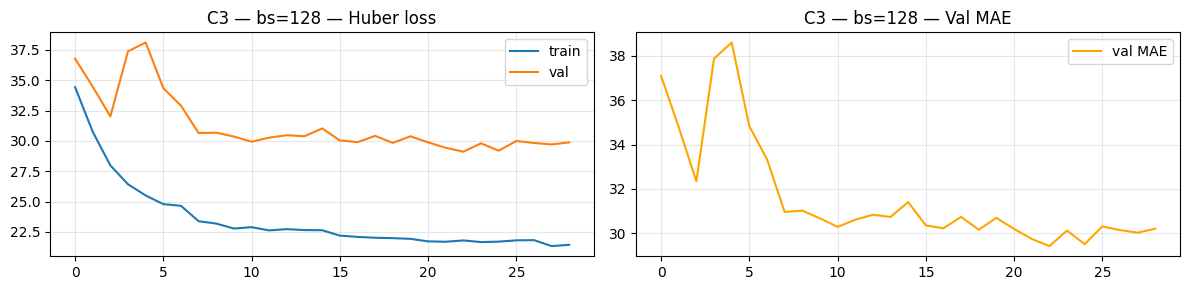

In [37]:
# ── C3: Batch size ────────────────────────────────────────────────────────────
print('=== C3: Batch size ===')
for bs in [32, 64, 128]:
    print(f'\n-- batch_size={bs} --')
    tr_l, va_l = make_loaders(X_train_best, y_train_best, X_val_best, y_val_best, bs)
    m = fresh_model()
    mae, rmse, ep, hist = train_and_eval(m, tr_l, va_l,
        optimizer_name=BEST_C1_OPTIMIZER, lr=BEST_C2_LR,
        scheduler_name=BEST_A_SCHEDULER, save_path=f'best_C3_bs{bs}.pt')
    plot_history(hist, f'C3 — bs={bs}')
    log_run(f'C3-bs{bs}', 'C', BEST_B_FEATURE_SET, BEST_C1_OPTIMIZER,
            BEST_C2_LR, bs, ep, mae, rmse, 'C3-batch')

In [38]:
df_c3 = pd.DataFrame(results_log)
df_c3 = df_c3[df_c3['extra'] == 'C3-batch'].sort_values('val_mae')
display(df_c3[['run_id', 'batch_size', 'val_mae', 'val_rmse', 'epochs_run']])
BEST_C3_BATCH = int(df_c3.iloc[0]['batch_size'])
print(f'\n-> Best batch size: {BEST_C3_BATCH}')

,run_id,batch_size,val_mae,val_rmse,epochs_run
11,C3-bs128,128,29.420172,172.583374,29
10,C3-bs64,64,29.926470,175.551056,27
9,C3-bs32,32,30.943502,184.600296,18



-> Best batch size: 128


=== C4: LR Scheduler ===

-- scheduler=StepLR --
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep   9 | train=24.51359 val=32.66882 MAE=33.00095
  -> Early stop at epoch 9


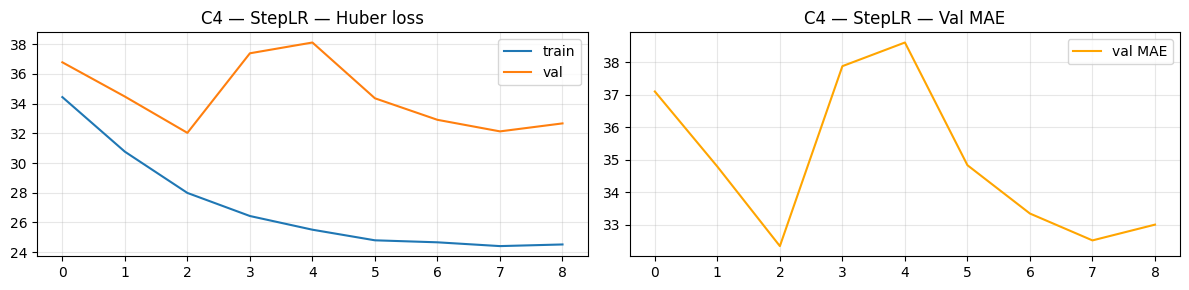


-- scheduler=CosineAnnealing --
  ep   5 | train=25.70466 val=36.71301 MAE=37.18462
  ep  10 | train=23.90368 val=30.17023 MAE=30.47874
  ep  15 | train=23.35995 val=31.88876 MAE=32.35954
  ep  16 | train=22.97368 val=30.79996 MAE=31.10790
  -> Early stop at epoch 16


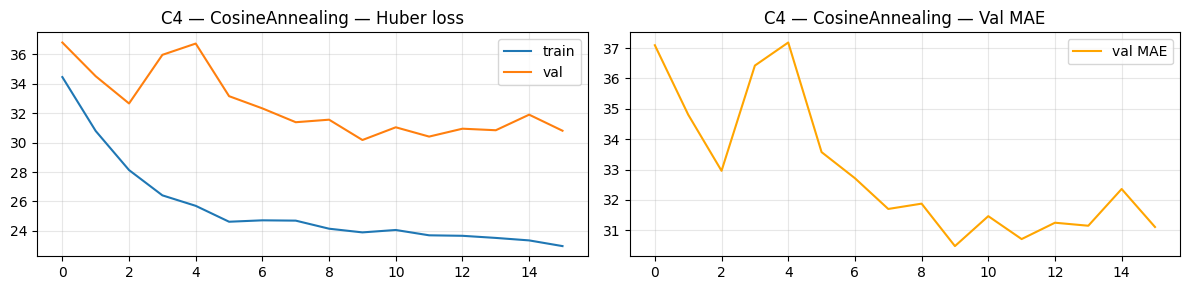


-- scheduler=ReduceOnPlateau --
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep  10 | train=22.78327 val=30.36397 MAE=30.67185
  ep  15 | train=22.64170 val=31.03813 MAE=31.40532
  ep  20 | train=21.93283 val=30.38422 MAE=30.69461
  ep  25 | train=21.70251 val=29.19830 MAE=29.50634
  ep  29 | train=21.43820 val=29.88316 MAE=30.20553
  -> Early stop at epoch 29


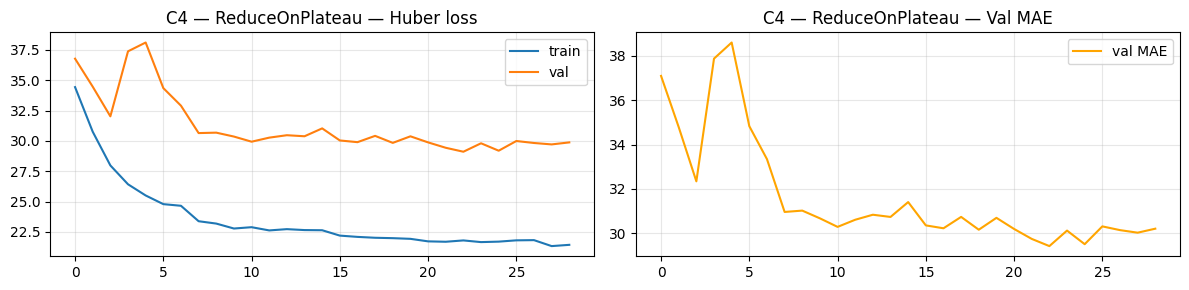

In [39]:
# ── C4: LR Scheduler ─────────────────────────────────────────────────────────
print('=== C4: LR Scheduler ===')
tr_l, va_l = make_loaders(X_train_best, y_train_best, X_val_best, y_val_best, BEST_C3_BATCH)
for sched in ['StepLR', 'CosineAnnealing', 'ReduceOnPlateau']:
    print(f'\n-- scheduler={sched} --')
    m = fresh_model()
    mae, rmse, ep, hist = train_and_eval(m, tr_l, va_l,
        optimizer_name=BEST_C1_OPTIMIZER, lr=BEST_C2_LR,
        scheduler_name=sched, save_path=f'best_C4_{sched}.pt')
    plot_history(hist, f'C4 — {sched}')
    log_run(f'C4-{sched}', 'C', BEST_B_FEATURE_SET, BEST_C1_OPTIMIZER,
            BEST_C2_LR, BEST_C3_BATCH, ep, mae, rmse, 'C4-scheduler')

In [40]:
df_c4 = pd.DataFrame(results_log)
df_c4 = df_c4[df_c4['extra'] == 'C4-scheduler'].sort_values('val_mae')
display(df_c4[['run_id', 'val_mae', 'val_rmse', 'epochs_run']])
BEST_C4_SCHEDULER = df_c4.iloc[0]['run_id'].replace('C4-', '')
print(f'\n-> Best scheduler: {BEST_C4_SCHEDULER}')

,run_id,val_mae,val_rmse,epochs_run
14,C4-ReduceOnPlateau,29.420172,172.583374,29
13,C4-CosineAnnealing,30.478741,177.844193,16
12,C4-StepLR,32.340714,200.485535,9



-> Best scheduler: ReduceOnPlateau


=== C5: Early stopping patience ===

-- patience=5 --
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep  10 | train=22.78327 val=30.36397 MAE=30.67185
  ep  15 | train=22.64170 val=31.03813 MAE=31.40532
  ep  16 | train=22.19921 val=30.04338 MAE=30.35405
  -> Early stop at epoch 16


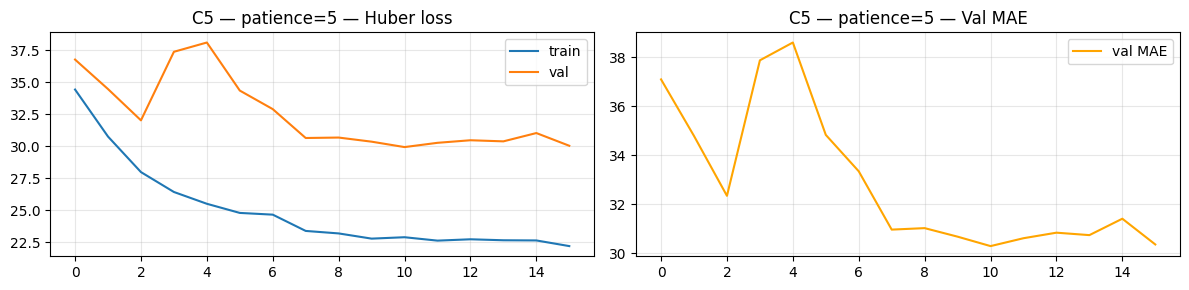


-- patience=10 --
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep  10 | train=22.78327 val=30.36397 MAE=30.67185
  ep  15 | train=22.64170 val=31.03813 MAE=31.40532
  ep  20 | train=21.93283 val=30.38422 MAE=30.69461
  ep  25 | train=21.70251 val=29.19830 MAE=29.50634
  ep  30 | train=21.36272 val=29.41324 MAE=29.72668
  ep  33 | train=21.09447 val=29.41430 MAE=29.72065
  -> Early stop at epoch 33


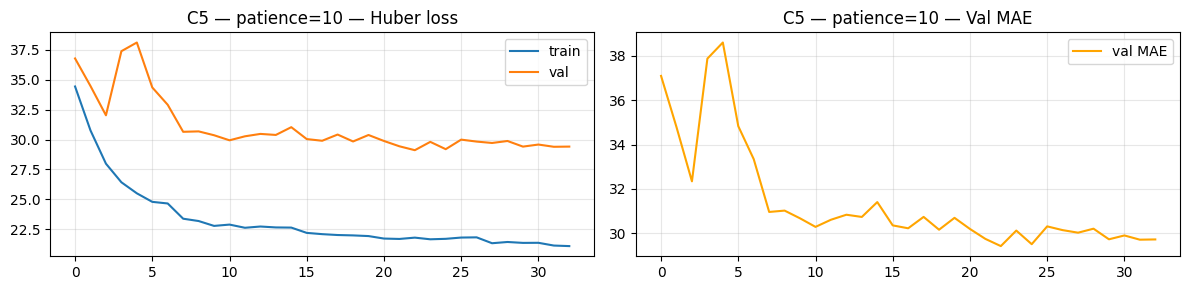

In [41]:
# ── C5: Early stopping patience ───────────────────────────────────────────────
print('=== C5: Early stopping patience ===')
for pat in [5, 10]:
    print(f'\n-- patience={pat} --')
    m = fresh_model()
    mae, rmse, ep, hist = train_and_eval(m, tr_l, va_l,
        optimizer_name=BEST_C1_OPTIMIZER, lr=BEST_C2_LR,
        scheduler_name=BEST_C4_SCHEDULER, patience=pat,
        save_path=f'best_C5_pat{pat}.pt')
    plot_history(hist, f'C5 — patience={pat}')
    log_run(f'C5-pat{pat}', 'C', BEST_B_FEATURE_SET, BEST_C1_OPTIMIZER,
            BEST_C2_LR, BEST_C3_BATCH, ep, mae, rmse, f'C5-patience={pat}')

In [42]:
# ── Block C summary ───────────────────────────────────────────────────────────
df_all = pd.DataFrame(results_log)
block_c = df_all[df_all['block'] == 'C'].sort_values('val_mae')
display(block_c[['run_id', 'extra', 'optimizer', 'lr', 'batch_size', 'val_mae', 'val_rmse', 'epochs_run']])

best_c = block_c.iloc[0]
BEST_C5_PATIENCE = int(best_c['extra'].split('=')[-1]) if 'patience' in best_c['extra'] else PATIENCE
print(f'\n-> Best Block C config:')
print(f'   optimizer={BEST_C1_OPTIMIZER}, lr={BEST_C2_LR}, batch={BEST_C3_BATCH}')
print(f'   scheduler={BEST_C4_SCHEDULER}, patience={BEST_C5_PATIENCE}')

,run_id,extra,optimizer,lr,batch_size,val_mae,val_rmse,epochs_run
5,C1-RMSProp,C1-optimizer,RMSProp,0.0010,128,29.420172,172.583374,29
7,C2-lr0.001,C2-lr,RMSProp,0.0010,128,29.420172,172.583374,29
14,C4-ReduceOnPlateau,C4-scheduler,RMSProp,0.0010,128,29.420172,172.583374,29
11,C3-bs128,C3-batch,RMSProp,0.0010,128,29.420172,172.583374,29
16,C5-pat10,C5-patience=10,RMSProp,0.0010,128,29.420172,172.583374,33
10,C3-bs64,C3-batch,RMSProp,0.0010,64,29.926470,175.551056,27
15,C5-pat5,C5-patience=5,RMSProp,0.0010,128,30.286776,176.203583,16
4,C1-Adam,C1-optimizer,Adam,0.0010,128,30.330282,174.937408,31
13,C4-CosineAnnealing,C4-scheduler,RMSProp,0.0010,128,30.478741,177.844193,16
9,C3-bs32,C3-batch,RMSProp,0.0010,32,30.943502,184.600296,18



-> Best Block C config:
   optimizer=RMSProp, lr=0.001, batch=128
   scheduler=ReduceOnPlateau, patience=6


---
## Block D — Architecture Depth & Regularisation

**Fixed:** best config from A + B + C.  
**Variable:** one architectural parameter at a time.

| Exp | Variable | Values tested |
|-----|----------|---------------|
| D1  | Number of LSTM layers | 1, 2, 3 |
| D2  | Hidden size | 32, 64, 128 |
| D3  | Dropout | 0.0, 0.2, 0.5 |

In [43]:
# Loaders for all D experiments (best batch size from C)
tr_l, va_l = make_loaders(X_train_best, y_train_best, X_val_best, y_val_best, BEST_C3_BATCH)

def train_d(model, run_id, extra):
    """Run one D experiment with best C config."""
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  params: {n_params:,}')
    mae, rmse, ep, hist = train_and_eval(
        model, tr_l, va_l,
        optimizer_name=BEST_C1_OPTIMIZER, lr=BEST_C2_LR,
        scheduler_name=BEST_C4_SCHEDULER, patience=BEST_C5_PATIENCE,
        save_path=f'best_{run_id}.pt')
    plot_history(hist, run_id)
    log_run(run_id, 'D', BEST_B_FEATURE_SET, BEST_C1_OPTIMIZER,
            BEST_C2_LR, BEST_C3_BATCH, ep, mae, rmse, extra)
    return mae

In [ ]:
# ── D1: Number of LSTM layers ─────────────────────────────────────────────────
print('=== D1: Number of LSTM layers ===')
for n_layers in [1, 2, 3]:
    print(f'\n-- num_layers={n_layers} --')
    torch.manual_seed(SEED)
    m = LSTMForecaster(input_size=INPUT_SIZE_BEST, hidden_size=BEST_A_HIDDEN,
        num_layers=n_layers, dropout=BEST_A_DROPOUT).to(DEVICE)
    train_d(m, f'D1-layers{n_layers}', f'D1-layers={n_layers}')

=== D1: Number of LSTM layers ===

-- num_layers=1 --
  params: 23,361


In [ ]:
df_d1 = pd.DataFrame(results_log)
df_d1 = df_d1[df_d1['extra'].str.startswith('D1')].sort_values('val_mae')
display(df_d1[['run_id', 'extra', 'val_mae', 'val_rmse', 'epochs_run']])
BEST_D1_LAYERS = int(df_d1.iloc[0]['extra'].split('=')[-1])
print(f'\n-> Best num_layers: {BEST_D1_LAYERS}')

In [ ]:
# ── D2: Hidden size ───────────────────────────────────────────────────────────
print('=== D2: Hidden size ===')
for hs in [32, 64, 128]:
    print(f'\n-- hidden_size={hs} --')
    torch.manual_seed(SEED)
    m = LSTMForecaster(input_size=INPUT_SIZE_BEST, hidden_size=hs,
        num_layers=BEST_D1_LAYERS, dropout=BEST_A_DROPOUT).to(DEVICE)
    train_d(m, f'D2-hidden{hs}', f'D2-hidden={hs}')

In [ ]:
df_d2 = pd.DataFrame(results_log)
df_d2 = df_d2[df_d2['extra'].str.startswith('D2')].sort_values('val_mae')
display(df_d2[['run_id', 'extra', 'val_mae', 'val_rmse', 'epochs_run']])
BEST_D2_HIDDEN = int(df_d2.iloc[0]['extra'].split('=')[-1])
print(f'\n-> Best hidden_size: {BEST_D2_HIDDEN}')

In [ ]:
# ── D3: Dropout ───────────────────────────────────────────────────────────────
print('=== D3: Dropout ===')
for drop in [0.0, 0.2, 0.5]:
    print(f'\n-- dropout={drop} --')
    torch.manual_seed(SEED)
    m = LSTMForecaster(input_size=INPUT_SIZE_BEST, hidden_size=BEST_D2_HIDDEN,
        num_layers=BEST_D1_LAYERS, dropout=drop).to(DEVICE)
    train_d(m, f'D3-drop{drop}', f'D3-dropout={drop}')

In [ ]:
df_d3 = pd.DataFrame(results_log)
df_d3 = df_d3[df_d3['extra'].str.startswith('D3')].sort_values('val_mae')
display(df_d3[['run_id', 'extra', 'val_mae', 'val_rmse', 'epochs_run']])
BEST_D3_DROPOUT = float(df_d3.iloc[0]['extra'].split('=')[-1])
print(f'\n-> Best dropout: {BEST_D3_DROPOUT}')

---
## Summary — All Blocks

In [ ]:
df_all = pd.DataFrame(results_log)

print('\n== Full experiment log ==')
display(df_all[['run_id', 'block', 'feature_set', 'optimizer', 'lr', 'batch_size',
                'val_mae', 'val_rmse', 'epochs_run', 'extra']]
        .sort_values(['block', 'val_mae'])
        .reset_index(drop=True))

# Best per block
print('\n== Best per block ==')
best_per = (df_all.sort_values('val_mae')
                  .groupby('block', sort=False)
                  .first()
                  .reset_index()
            [['block', 'run_id', 'val_mae', 'val_rmse', 'extra']])
display(best_per)

In [ ]:
# ── Final best config ─────────────────────────────────────────────────────────
print('== Best configuration found ==')
print(f'  Feature set  : {BEST_B_FEATURE_SET}')
print(f'  Optimizer    : {BEST_C1_OPTIMIZER}')
print(f'  Learning rate: {BEST_C2_LR}')
print(f'  Batch size   : {BEST_C3_BATCH}')
print(f'  Scheduler    : {BEST_C4_SCHEDULER}')
print(f'  Patience     : {BEST_C5_PATIENCE}')
print(f'  LSTM layers  : {BEST_D1_LAYERS}')
print(f'  Hidden size  : {BEST_D2_HIDDEN}')
print(f'  Dropout      : {BEST_D3_DROPOUT}')